# H10: Integrated Multivariate Spleen Architecture Phenotyping

**Aim:** Synthesize all morphological features (from H1–H5) into PCA and hierarchical
clustering to identify dominant patterns of architectural variation and how they map to
genotype, clinical, and platform variables.

**Approach:**
1. Build per-sample feature matrix (~20 morphological features)
2. PCA on z-scored features to identify principal axes of variation
3. Hierarchical clustering (Ward linkage) to group samples
4. Map PCs and clusters to genotype, clinical, and platform variables
5. Descriptive centroid-based projection for genotype separation

**Caveats:**
- p >> n problem (20 features, 13–15 samples)
- Results are descriptive, not hypothesis-testing
- CODEX vs Phenocycler platform confound
- All analyses run dual cohort: All samples and Phenocycler-only

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from data_utils import (
    load_all_data, build_feature_matrix, load_clinical, platform_diagnostic,
    GENO_ORDER, GENO_PALETTE, CODEX_SAMPLES,
    setup_style, save_figure, save_table,
)

setup_style()

# Load data
df = load_all_data()
feat = build_feature_matrix(df)
clin = load_clinical()

# Merge clinical
merged = feat.reset_index().merge(
    clin.drop(columns=['Genotype', 'Platform']), on='Sample', how='left')
merged = merged.set_index('Sample')

# Feature columns (numeric morphological)
morph_cols = [c for c in feat.columns if c not in ('Genotype', 'Platform')]
merged_pc = merged[merged['Platform'] == 'Phenocycler'].copy()

print(f'Samples: {len(merged)} (All), {len(merged_pc)} (PC-only)')
print(f'Morphological features: {len(morph_cols)}')

Samples: 13 (All), 8 (PC-only)
Morphological features: 20


## Section 1: Feature QC

Features with missing values:
Vessel_median_circularity    3
Vessel_median_solidity       3
Vessel_median_elongation     3
dtype: int64

Features with outliers (|z|>3): {'PALS_norm_density': 1}
Saved: analysis/figures/H10_feature_correlation.png


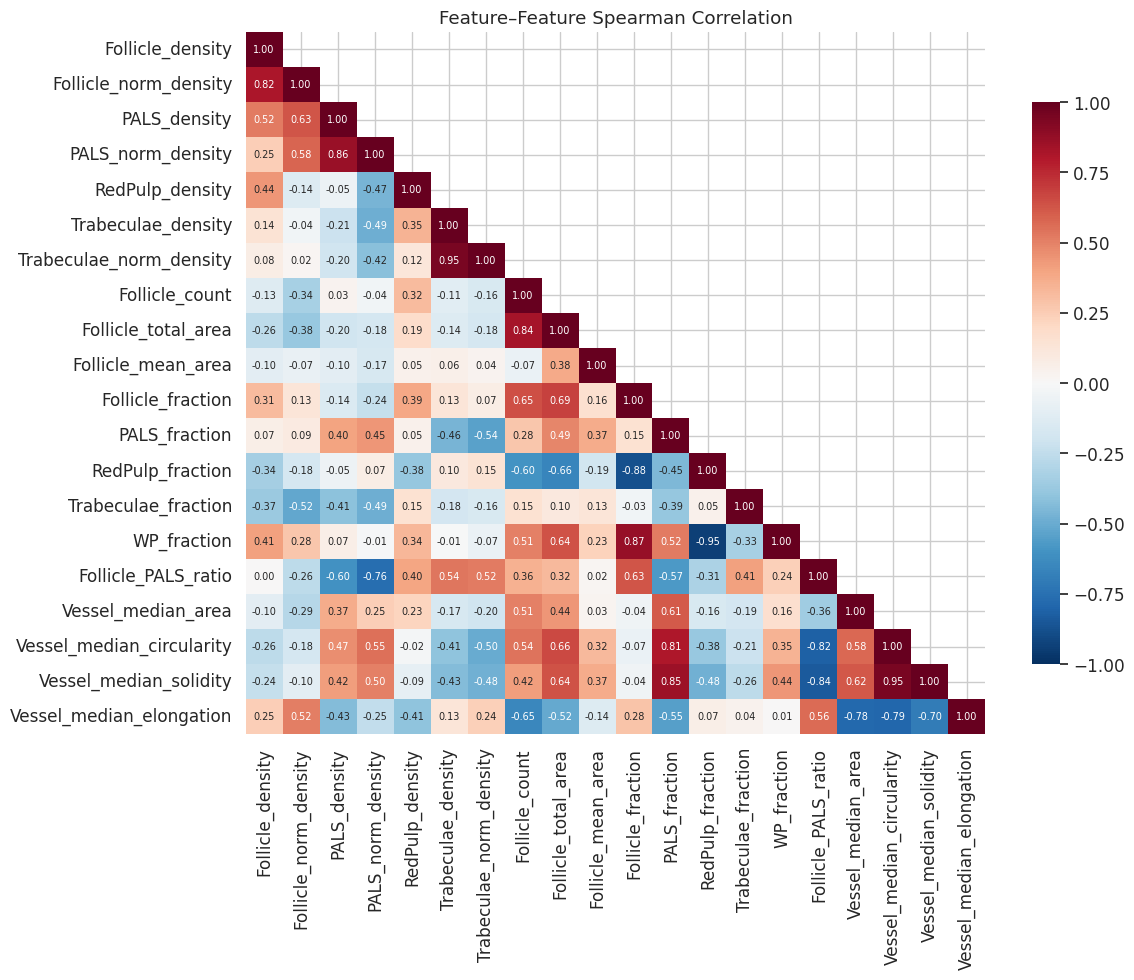

In [2]:
# Missingness check
missing = merged[morph_cols].isna().sum()
if missing.any():
    print('Features with missing values:')
    print(missing[missing > 0])
else:
    print('No missing values in morphological features.')

# Outlier flags (z > 3)
z_scores = merged[morph_cols].apply(lambda x: (x - x.mean()) / x.std())
outliers = (z_scores.abs() > 3).sum()
if outliers.any():
    print(f'\nFeatures with outliers (|z|>3): {outliers[outliers > 0].to_dict()}')
else:
    print('No outliers (|z|>3) detected.')

# Feature-feature correlation heatmap
corr = merged[morph_cols].corr(method='spearman')
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, annot=True, fmt='.2f', annot_kws={'fontsize': 7},
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature\u2013Feature Spearman Correlation')
fig.tight_layout()
save_figure(fig, 'H10_feature_correlation')
plt.show()

## Section 2: PCA

In [ ]:
# Z-score features and run PCA — include Platform as binary feature
X = merged[morph_cols].dropna(axis=1)  # drop any all-NaN columns
X['Platform_CODEX'] = (merged['Platform'] == 'CODEX').astype(float)
valid_cols = X.columns.tolist()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_components = min(len(merged), len(valid_cols))
pca = PCA(n_components=n_components)
scores = pca.fit_transform(X_scaled)

# Store scores
pc_names = [f'PC{i+1}' for i in range(n_components)]
scores_df = pd.DataFrame(scores, index=merged.index, columns=pc_names)
scores_df = scores_df.join(merged[['Genotype', 'Platform']])

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.bar(range(1, n_components + 1), pca.explained_variance_ratio_,
       color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Scree Plot')

ax = axes[1]
cumvar = np.cumsum(pca.explained_variance_ratio_)
ax.plot(range(1, n_components + 1), cumvar, 'o-', color='coral')
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, label='80%')
ax.axhline(0.9, color='gray', linestyle=':', linewidth=0.8, label='90%')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Cumulative Variance')
ax.legend()

fig.suptitle(f'PCA on {len(valid_cols)} Features incl. Platform (n={len(merged)})',
             fontsize=14, y=1.02)
fig.tight_layout()
save_figure(fig, 'H10_scree_plot')
plt.show()

print(f'Variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, '
      f'PC2={pca.explained_variance_ratio_[1]:.1%}, '
      f'PC3={pca.explained_variance_ratio_[2]:.1%}')
print(f'Components for 80% variance: {np.searchsorted(cumvar, 0.8) + 1}')

Saved: analysis/figures/H10_pca_biplot.png


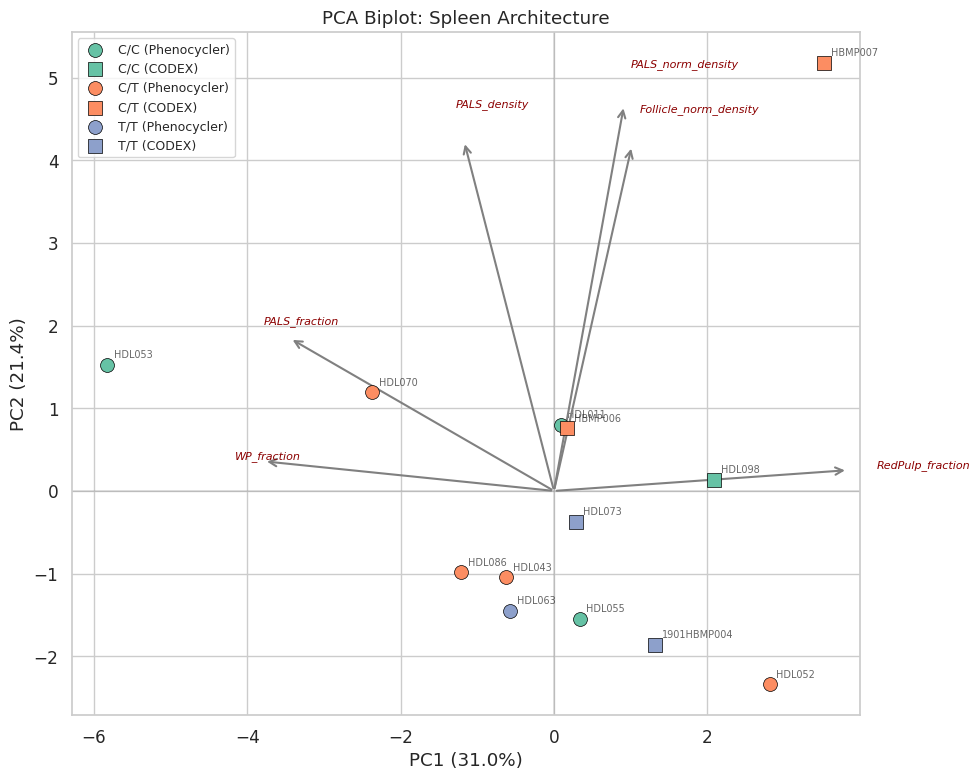

In [4]:
# PC1 vs PC2 biplot with top-6 loading arrows
loadings = pd.DataFrame(pca.components_.T, index=valid_cols, columns=pc_names)

fig, ax = plt.subplots(figsize=(10, 8))

# Plot samples
markers = {'Phenocycler': 'o', 'CODEX': 's'}
for geno in GENO_ORDER:
    for plat, marker in markers.items():
        mask = (scores_df['Genotype'] == geno) & (scores_df['Platform'] == plat)
        sub = scores_df[mask]
        ax.scatter(sub['PC1'], sub['PC2'], c=[GENO_PALETTE[geno]], marker=marker,
                   s=100, edgecolors='black', linewidths=0.5,
                   label=f'{geno} ({plat})', zorder=5)
        # Label samples
        for sid in sub.index:
            ax.annotate(sid, (sub.loc[sid, 'PC1'], sub.loc[sid, 'PC2']),
                       fontsize=7, alpha=0.7, xytext=(5, 5),
                       textcoords='offset points')

# Top-6 loading arrows
loading_magnitude = (loadings['PC1']**2 + loadings['PC2']**2)**0.5
top6_features = loading_magnitude.nlargest(6).index
scale = max(abs(scores[:, 0]).max(), abs(scores[:, 1]).max()) / max(abs(loadings[['PC1', 'PC2']]).values.max(), 1e-10) * 0.8

for feat_name in top6_features:
    ax.annotate('', xy=(loadings.loc[feat_name, 'PC1'] * scale,
                        loadings.loc[feat_name, 'PC2'] * scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    ax.text(loadings.loc[feat_name, 'PC1'] * scale * 1.1,
            loadings.loc[feat_name, 'PC2'] * scale * 1.1,
            feat_name, fontsize=8, color='darkred', fontstyle='italic')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA Biplot: Spleen Architecture')
ax.legend(loc='best', fontsize=9)
ax.axhline(0, color='gray', linewidth=0.3)
ax.axvline(0, color='gray', linewidth=0.3)
fig.tight_layout()
save_figure(fig, 'H10_pca_biplot')
plt.show()

Saved: analysis/figures/H10_pca_panels.png


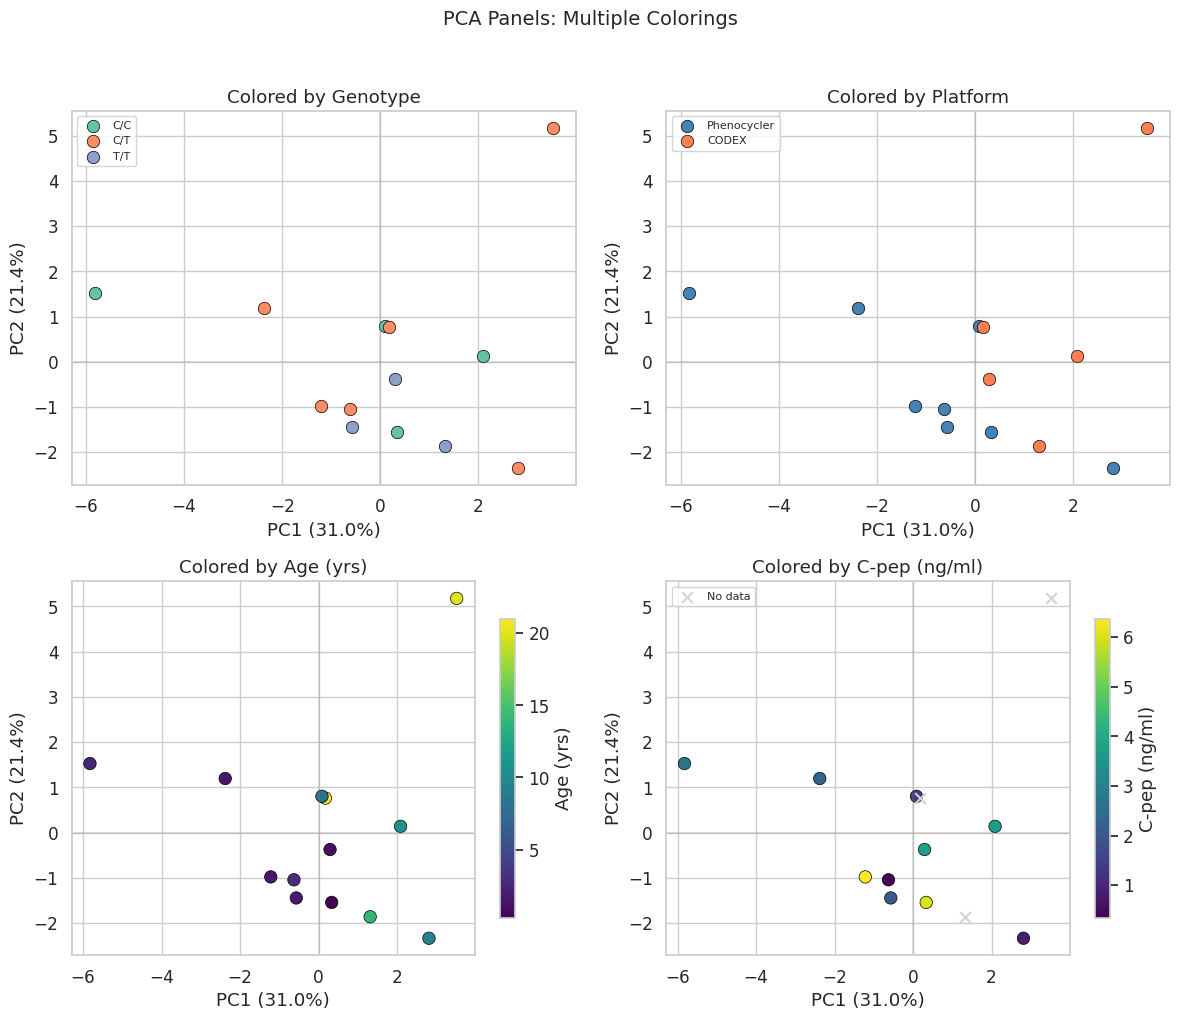

In [5]:
# 2x2 panels: PC1 vs PC2 colored by different variables
from matplotlib.colors import Normalize

color_vars = [
    ('Genotype', 'categorical'),
    ('Platform', 'categorical'),
    ('Age (yrs)', 'continuous'),
    ('C-pep (ng/ml)', 'continuous'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, (var, vtype) in enumerate(color_vars):
    ax = axes[idx // 2, idx % 2]
    if var not in merged.columns:
        ax.set_visible(False)
        continue
    if vtype == 'categorical':
        if var == 'Genotype':
            for geno in GENO_ORDER:
                mask = scores_df['Genotype'] == geno
                ax.scatter(scores_df.loc[mask, 'PC1'], scores_df.loc[mask, 'PC2'],
                           c=[GENO_PALETTE[geno]], label=geno, s=80,
                           edgecolors='black', linewidths=0.5)
        elif var == 'Platform':
            plat_colors = {'Phenocycler': 'steelblue', 'CODEX': 'coral'}
            for plat in ['Phenocycler', 'CODEX']:
                mask = scores_df['Platform'] == plat
                ax.scatter(scores_df.loc[mask, 'PC1'], scores_df.loc[mask, 'PC2'],
                           c=[plat_colors[plat]], label=plat, s=80,
                           edgecolors='black', linewidths=0.5)
        ax.legend(fontsize=8)
    else:
        vals = merged[var]
        valid_mask = vals.notna()
        sc = ax.scatter(scores_df.loc[valid_mask, 'PC1'],
                        scores_df.loc[valid_mask, 'PC2'],
                        c=vals[valid_mask], cmap='viridis', s=80,
                        edgecolors='black', linewidths=0.5)
        plt.colorbar(sc, ax=ax, shrink=0.8, label=var)
        # Mark NaN samples
        nan_mask = vals.isna()
        if nan_mask.any():
            ax.scatter(scores_df.loc[nan_mask, 'PC1'],
                       scores_df.loc[nan_mask, 'PC2'],
                       c='lightgray', marker='x', s=60, label='No data')
            ax.legend(fontsize=8)

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.set_title(f'Colored by {var}')
    ax.axhline(0, color='gray', linewidth=0.3)
    ax.axvline(0, color='gray', linewidth=0.3)

fig.suptitle('PCA Panels: Multiple Colorings', fontsize=14, y=1.02)
fig.tight_layout()
save_figure(fig, 'H10_pca_panels')
plt.show()

## Section 3: PC Loadings

Saved: analysis/figures/H10_pc_loadings.png


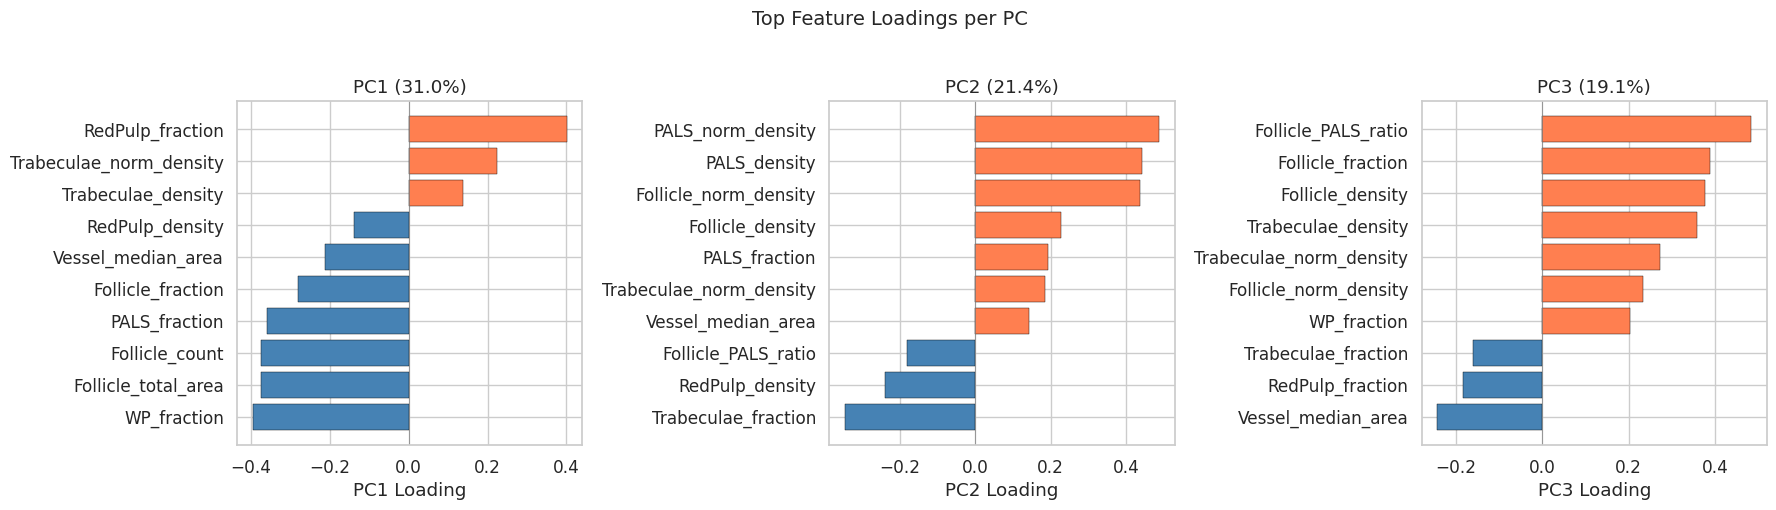

In [6]:
# Horizontal bar charts: top 10 features by |loading| on PC1, PC2, PC3
n_top = min(10, len(valid_cols))
n_pcs = min(3, n_components)

fig, axes = plt.subplots(1, n_pcs, figsize=(6 * n_pcs, 5))
if n_pcs == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    pc = f'PC{i+1}'
    top = loadings[pc].abs().nlargest(n_top)
    ordered = loadings.loc[top.index, pc].sort_values()
    colors = ['coral' if v > 0 else 'steelblue' for v in ordered]
    ax.barh(ordered.index, ordered.values, color=colors,
            edgecolor='black', linewidth=0.3)
    ax.set_xlabel(f'{pc} Loading')
    ax.set_title(f'{pc} ({pca.explained_variance_ratio_[i]:.1%})')
    ax.axvline(0, color='gray', linewidth=0.5)

fig.suptitle('Top Feature Loadings per PC', fontsize=14, y=1.02)
fig.tight_layout()
save_figure(fig, 'H10_pc_loadings')
plt.show()

In [7]:
# Spearman: PC scores vs external variables
external_vars = {
    'Genotype_dosage': merged['Genotype'].astype(str).map({'C/C': 0, 'C/T': 1, 'T/T': 2}),
    'Platform_code': (merged['Platform'] == 'CODEX').astype(int),
}
for cvar in ['Age (yrs)', 'BMI', 'C-pep (ng/ml)', 'HbA1c']:
    if cvar in merged.columns:
        external_vars[cvar] = merged[cvar]

pc_corr_rows = []
for pc in pc_names[:5]:
    for var_name, var_vals in external_vars.items():
        valid = pd.DataFrame({'pc': scores_df[pc], 'var': var_vals}).dropna()
        if len(valid) >= 4:
            r, p = spearmanr(valid['pc'], valid['var'])
        else:
            r, p = np.nan, np.nan
        pc_corr_rows.append({'PC': pc, 'Variable': var_name, 'rho': r, 'p': p})

pc_corr_df = pd.DataFrame(pc_corr_rows)
save_table(pc_corr_df, 'H10_pc_correlations')

# Pivot for display
pivot_rho = pc_corr_df.pivot(index='Variable', columns='PC', values='rho')
pivot_p = pc_corr_df.pivot(index='Variable', columns='PC', values='p')
print('PC \u00d7 External Variable Correlations (Spearman \u03c1):')
display(pivot_rho.round(3))
print('\np-values:')
display(pivot_p.round(3))

Saved: analysis/tables/H10_pc_correlations.csv
PC × External Variable Correlations (Spearman ρ):


PC,PC1,PC2,PC3,PC4,PC5
Variable,,,,,
Age (yrs),0.478,0.181,0.022,-0.198,-0.297
BMI,0.203,0.440,0.451,-0.071,0.247
C-pep (ng/ml),-0.042,0.115,0.261,0.248,0.394
Genotype_dosage,0.083,-0.360,0.396,-0.177,-0.121
HbA1c,-0.204,0.366,0.672,-0.153,0.366
Platform_code,0.592,0.169,0.423,-0.169,0.169



p-values:


PC,PC1,PC2,PC3,PC4,PC5
Variable,,,,,
Age (yrs),0.098,0.553,0.943,0.517,0.325
BMI,0.505,0.133,0.122,0.817,0.415
C-pep (ng/ml),0.907,0.751,0.467,0.489,0.260
Genotype_dosage,0.788,0.227,0.181,0.563,0.694
HbA1c,0.598,0.333,0.047,0.694,0.333
Platform_code,0.033,0.581,0.150,0.581,0.581


## Section 4: Hierarchical Clustering

In [ ]:
# Ward linkage dendrogram
Z = linkage(X_scaled, method='ward')

# Color leaves by genotype
geno_color_map = {g: GENO_PALETTE[g] for g in GENO_ORDER}

fig, ax = plt.subplots(figsize=(12, 5))
dn = dendrogram(Z, labels=merged.index.tolist(), ax=ax, leaf_rotation=45,
                leaf_font_size=10, above_threshold_color='gray')

# Color leaf labels by genotype
xlbls = ax.get_xticklabels()
for lbl in xlbls:
    sid = lbl.get_text()
    geno = str(merged.loc[sid, 'Genotype']) if sid in merged.index else 'unknown'
    lbl.set_color(geno_color_map.get(geno, 'black'))
    lbl.set_fontweight('bold')

ax.set_ylabel('Ward Distance')
ax.set_title('Hierarchical Clustering of Spleen Architecture')

# Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w',
                          markerfacecolor=GENO_PALETTE[g], label=g, markersize=10)
                   for g in GENO_ORDER]
ax.legend(handles=legend_elements, title='Genotype', loc='upper right')

fig.tight_layout()
save_figure(fig, 'H10_dendrogram')
plt.show()

In [ ]:
# Cut at k=3 clusters, check composition vs genotype
k = 3
clusters = fcluster(Z, t=k, criterion='maxclust')
merged['Cluster'] = clusters

# Cluster composition
comp = pd.crosstab(merged['Cluster'], merged['Genotype'])
print('Cluster \u00d7 Genotype composition:')
display(comp)

# Platform composition
plat_comp = pd.crosstab(merged['Cluster'], merged['Platform'])
print('\nCluster \u00d7 Platform composition:')
display(plat_comp)

# Fisher's exact test (for each pair of genotypes within clusters)
from scipy.stats import chi2_contingency
if comp.shape[0] >= 2 and comp.shape[1] >= 2:
    chi2, p_chi, dof, expected = chi2_contingency(comp)
    print(f'\nChi-squared test (Cluster \u00d7 Genotype): \u03c7\u00b2={chi2:.2f}, p={p_chi:.3f}, dof={dof}')
    print('(Note: expected counts may be too small for valid chi-squared)')

save_table(comp.reset_index(), 'H10_cluster_composition')

In [ ]:
# Clustermap: features x samples with genotype/platform row colors
row_colors_geno = merged['Genotype'].astype(str).map(GENO_PALETTE)
row_colors_plat = merged['Platform'].map({'Phenocycler': 'steelblue', 'CODEX': 'coral'})
row_colors = pd.DataFrame({
    'Genotype': row_colors_geno,
    'Platform': row_colors_plat,
})

g = sns.clustermap(
    pd.DataFrame(X_scaled, index=merged.index, columns=valid_cols),
    method='ward', cmap='RdBu_r', center=0, figsize=(14, 8),
    row_colors=row_colors, dendrogram_ratio=0.15,
    cbar_kws={'label': 'Z-score'},
    xticklabels=True, yticklabels=True,
)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=8, rotation=45, ha='right')
g.fig.suptitle('Clustermap: Spleen Architecture Features', y=1.02, fontsize=14)

save_figure(g.fig, 'H10_clustermap')
plt.show()

## Section 5: Platform Sensitivity

In [ ]:
# PCA on Phenocycler-only
X_pc = merged_pc[morph_cols].dropna(axis=1)
valid_cols_pc = X_pc.columns.tolist()
X_pc_scaled = StandardScaler().fit_transform(X_pc)

n_comp_pc = min(len(merged_pc), len(valid_cols_pc))
pca_pc = PCA(n_components=n_comp_pc)
scores_pc = pca_pc.fit_transform(X_pc_scaled)
scores_pc_df = pd.DataFrame(scores_pc[:, :2], index=merged_pc.index,
                            columns=['PC1', 'PC2'])
scores_pc_df = scores_pc_df.join(merged_pc[['Genotype', 'Platform']])

# Side-by-side biplot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, sdf, pca_obj, title in [
    (axes[0], scores_df, pca, f'All (n={len(merged)})'),
    (axes[1], scores_pc_df, pca_pc, f'Phenocycler-only (n={len(merged_pc)})')]:
    for geno in GENO_ORDER:
        mask = sdf['Genotype'] == geno
        sub = sdf[mask]
        marker = 'o'
        ax.scatter(sub['PC1'], sub['PC2'], c=[GENO_PALETTE[geno]], marker=marker,
                   s=80, edgecolors='black', linewidths=0.5, label=geno)
        for sid in sub.index:
            ax.annotate(sid, (sub.loc[sid, 'PC1'], sub.loc[sid, 'PC2']),
                       fontsize=7, alpha=0.7, xytext=(5, 5),
                       textcoords='offset points')
    ax.set_xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]:.1%})')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.axhline(0, color='gray', linewidth=0.3)
    ax.axvline(0, color='gray', linewidth=0.3)

fig.suptitle('PCA: Platform Sensitivity Comparison', fontsize=14, y=1.02)
fig.tight_layout()
save_figure(fig, 'H10_pca_platform_comparison')
plt.show()

# Platform diagnostic
plat_diag = platform_diagnostic(merged.reset_index(), morph_cols)
print('\nPlatform diagnostic (Mann-Whitney CODEX vs Phenocycler):')
display(plat_diag.sort_values('p'))

## Section 6: Descriptive LDA Projection

In [ ]:
# Project onto C/C-T/T centroid axis
cc_mask = merged['Genotype'] == 'C/C'
tt_mask = merged['Genotype'] == 'T/T'

if cc_mask.sum() >= 1 and tt_mask.sum() >= 1:
    centroid_cc = X_scaled[cc_mask.values].mean(axis=0)
    centroid_tt = X_scaled[tt_mask.values].mean(axis=0)
    axis = centroid_tt - centroid_cc
    axis_norm = axis / np.linalg.norm(axis)

    projections = X_scaled @ axis_norm
    proj_df = pd.DataFrame({
        'Sample': merged.index,
        'Projection': projections,
        'Genotype': merged['Genotype'].values,
        'Platform': merged['Platform'].values,
    })

    fig, ax = plt.subplots(figsize=(8, 5))
    markers = {'Phenocycler': 'o', 'CODEX': 's'}
    for geno in GENO_ORDER:
        for plat, marker in markers.items():
            sub = proj_df[(proj_df['Genotype'] == geno) & (proj_df['Platform'] == plat)]
            ax.scatter([geno] * len(sub), sub['Projection'],
                       c=[GENO_PALETTE[geno]], marker=marker, s=80,
                       edgecolors='black', linewidths=0.5,
                       label=f'{plat}' if geno == GENO_ORDER[0] else '')
            for _, row in sub.iterrows():
                ax.annotate(row['Sample'], (geno, row['Projection']),
                           fontsize=7, alpha=0.7, xytext=(8, 0),
                           textcoords='offset points')

    ax.set_xlabel('Genotype')
    ax.set_ylabel('Projection onto C/C\u2192T/T axis')
    ax.set_title('Descriptive LDA Projection\n(C/C\u2013T/T centroid axis in feature space)')
    ax.legend(title='Platform')
    fig.tight_layout()
    save_figure(fig, 'H10_lda_projection')
    plt.show()
else:
    print('Insufficient samples for LDA projection.')

## Summary Tables

In [9]:
# Save feature matrix
save_table(merged[morph_cols + ['Genotype', 'Platform']].reset_index(), 'H10_feature_matrix')

# PCA results: variance explained
pca_var = pd.DataFrame({
    'PC': pc_names,
    'Eigenvalue': pca.explained_variance_,
    'Variance_Ratio': pca.explained_variance_ratio_,
    'Cumulative_Variance': np.cumsum(pca.explained_variance_ratio_),
})
save_table(pca_var, 'H10_pca_variance')

# PCA loadings
save_table(loadings.reset_index().rename(columns={'index': 'Feature'}), 'H10_pca_loadings')

# PCA scores
save_table(scores_df.reset_index(), 'H10_pca_scores')

# Statistical tests summary
stats_rows = []
for _, row in pc_corr_df.iterrows():
    if row['p'] < 0.1:
        stats_rows.append({
            'Test': f'Spearman ({row["PC"]} vs {row["Variable"]})',
            'Statistic': row['rho'], 'p': row['p']
        })

if 'p_chi' in dir():
    stats_rows.append({'Test': 'Chi-squared (Cluster x Genotype)',
                       'Statistic': chi2, 'p': p_chi})

stats_df = pd.DataFrame(stats_rows) if stats_rows else pd.DataFrame(
    columns=['Test', 'Statistic', 'p'])
save_table(stats_df, 'H10_statistical_tests')

print(f'\nSaved 6 output files.')

Saved: analysis/tables/H10_feature_matrix.csv
Saved: analysis/tables/H10_pca_variance.csv
Saved: analysis/tables/H10_pca_loadings.csv
Saved: analysis/tables/H10_pca_scores.csv
Saved: analysis/tables/H10_statistical_tests.csv

Saved 6 output files.


In [10]:
# Key findings summary
print('=' * 60)
print('H10: Multivariate Spleen Architecture \u2014 Key Findings')
print('=' * 60)

print(f'\nSamples: {len(merged)} (All), {len(merged_pc)} (PC-only)')
print(f'Features: {len(valid_cols)}')

print(f'\nPCA: PC1={pca.explained_variance_ratio_[0]:.1%}, '
      f'PC2={pca.explained_variance_ratio_[1]:.1%}, '
      f'PC3={pca.explained_variance_ratio_[2]:.1%}')

# Significant PC correlations
sig_pc = pc_corr_df[pc_corr_df['p'] < 0.1]
if len(sig_pc) > 0:
    print(f'\nSignificant PC correlations (p<0.1):')
    for _, r in sig_pc.iterrows():
        print(f'  {r["PC"]} vs {r["Variable"]}: \u03c1={r["rho"]:.3f}, p={r["p"]:.3f}')

# Cluster results
print(f'\nHierarchical clustering (k={k}):')
for c in sorted(merged['Cluster'].unique()):
    samps = merged[merged['Cluster'] == c].index.tolist()
    genos = merged.loc[samps, 'Genotype'].value_counts().to_dict()
    print(f'  Cluster {c}: {samps} \u2192 {genos}')

# Top loading features
print(f'\nTop PC1 features: {list(loadings["PC1"].abs().nlargest(5).index)}')
print(f'Top PC2 features: {list(loadings["PC2"].abs().nlargest(5).index)}')

H10: Multivariate Spleen Architecture — Key Findings

Samples: 13 (All), 8 (PC-only)
Features: 17

PCA: PC1=31.0%, PC2=21.4%, PC3=19.1%

Significant PC correlations (p<0.1):
  PC1 vs Platform_code: ρ=0.592, p=0.033
  PC1 vs Age (yrs): ρ=0.478, p=0.098
  PC3 vs HbA1c: ρ=0.672, p=0.047


NameError: name 'k' is not defined